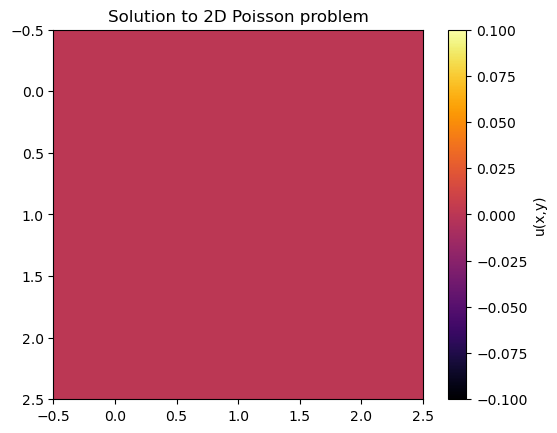

In [1]:
import numpy as np
import scipy.sparse.linalg
import matplotlib.pyplot as plt

from util.solver import assemble_poisson_problem
from util.solver import assemble_biharmonic_problem

N = 3  # grid size
bc_mask = np.zeros((N, N), dtype=np.uint8)
bc_value = np.zeros((N, N), dtype=np.float32)
f = np.zeros((N, N), dtype=np.float32)

# set boundary condition (u = 1 at top edge, 0 elsewhere)
# bc_mask[0, :] = 1
# bc_value[0, :] = 1.0

# assemble system
A, rhs = assemble_poisson_problem(bc_value, bc_mask, f)

# solve linear system
u = scipy.sparse.linalg.spsolve(A, rhs)

# reshape back to grid
u_grid = u.reshape(N, N)

# visualize
plt.imshow(u_grid, cmap="inferno")
plt.colorbar(label="u(x,y)")
plt.title("Solution to 2D Poisson problem")
plt.show()

In [2]:
np.set_printoptions(linewidth=200) 
print("Right-hand side (rhs):")
print(rhs.reshape(N, N))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)


Right-hand side (rhs):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Sparse matrix A (dense view) (9, 9):
[-4.  1.  0.  1.  0.  0.  0.  0.  0.]
[ 1. -4.  1.  0.  1.  0.  0.  0.  0.]
[ 0.  1. -4.  0.  0.  1.  0.  0.  0.]
[ 1.  0.  0. -4.  1.  0.  1.  0.  0.]
[ 0.  1.  0.  1. -4.  1.  0.  1.  0.]
[ 0.  0.  1.  0.  1. -4.  0.  0.  1.]
[ 0.  0.  0.  1.  0.  0. -4.  1.  0.]
[ 0.  0.  0.  0.  1.  0.  1. -4.  1.]
[ 0.  0.  0.  0.  0.  1.  0.  1. -4.]


In [ ]:
N2 = 5  # grid size
bc_mask = np.zeros((N2, N2), dtype=np.uint8)
bc_value = np.zeros((N2, N2), dtype=np.float32)
f = np.zeros((N2, N2), dtype=np.float32)
A, rhs = assemble_biharmonic_problem(bc_value, bc_mask, f)
np.set_printoptions(linewidth=200) 
print("Right-hand side (rhs):")
print(rhs.reshape(N2, N2))

print(f"\nSparse matrix A (dense view) {A.shape}:")
dense_A = A.toarray()
for row in dense_A:
    print(row)

ValueError: negative axis 1 index: -10